#House price prediction

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [84]:
# Load the dataset
try:
    df = pd.read_csv('AmesHousing.csv')
    print("Data loaded successfully!")
    print(f"Shape of the dataset: {df.shape}")
except FileNotFoundError:
    print("Error: 'AmesHousing.csv' not found. Please ensure the file is in the correct directory.")
    
# Display the first 5 rows to verify the load
print("\nFirst 5 rows of the dataset:")
print(df.head())

Data loaded successfully!
Shape of the dataset: (2930, 82)

First 5 rows of the dataset:
   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC  Fence Misc Feature  \
0   NaN       IR1          Lvl  ...         0     NaN    NaN          NaN   
1   NaN       Reg          Lvl  ...         0     NaN  MnPrv          NaN   
2   NaN       IR1          Lvl  ...         0     NaN    NaN         Gar2   
3   NaN       Reg          Lvl  ...         0     NaN    NaN          NaN   
4   NaN       IR1          Lvl  ...         0     NaN  MnPrv   


Data information (Types and Missing Values):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type     

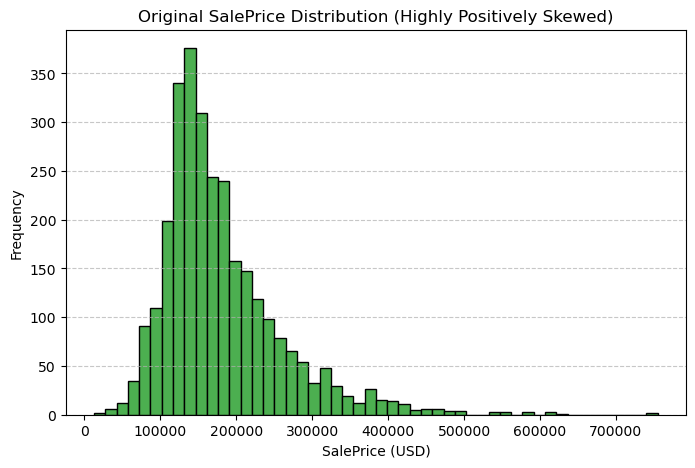

In [85]:
# Check data types and non-null values
print("\nData information (Types and Missing Values):")
df.info()

# Statistical summary of numerical features
import pandas as pd
import matplotlib.pyplot as plt

df_original = pd.read_csv('AmesHousing.csv') 

plt.figure(figsize=(8, 5))
plt.hist(df_original['SalePrice'], bins=50, edgecolor='black', color='#4CAF50')
plt.title('Original SalePrice Distribution (Highly Positively Skewed)')
plt.xlabel('SalePrice (USD)')
plt.ylabel('Frequency')
plt.ticklabel_format(style='plain', axis='x') 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

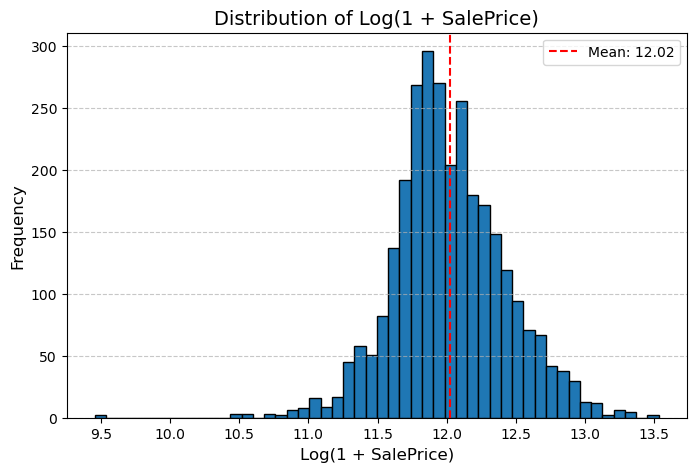

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('AmesHousing.csv') 

# Apply log transformation 
df['SalePrice'] = np.log1p(df['SalePrice'])

# --- Plotting Code ---
plt.figure(figsize=(8, 5))
plt.hist(df['SalePrice'], bins=50, edgecolor='black', color='#1f77b4')
plt.title('Distribution of Log(1 + SalePrice)', fontsize=14) 
plt.xlabel('Log(1 + SalePrice)', fontsize=12) 
plt.ylabel('Frequency', fontsize=12) 
mean_log_price = df['SalePrice'].mean()
plt.axvline(mean_log_price, color='red', linestyle='dashed', linewidth=1.5, label=f'Mean: {mean_log_price:.2f}')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

In [87]:
##Data Separation and Missing Value Imputation


X = df.drop(['SalePrice', 'Order', 'PID'], axis=1) 
y = df['SalePrice'] 

# --- Categorical Imputation (NA means 'None' for 90% of features) ---
# List of columns where NA logically means absence of the feature
cols_none = ['Pool QC', 'Misc Feature', 'Alley', 'Fence', 'Fireplace Qu', 
             'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond', 
             'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 
             'BsmtFin Type 2', 'Mas Vnr Type']
X[cols_none] = X[cols_none].fillna('None')

# --- Numerical Imputation (NA means 0 for area/count features) ---
# List of columns where NA logically means 0 square feet or 0 cars
cols_zero = ['Garage Yr Blt', 'Garage Area', 'Garage Cars', 'BsmtFin SF 1', 
             'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Bsmt Full Bath', 
             'Bsmt Half Bath', 'Mas Vnr Area']
X[cols_zero] = X[cols_zero].fillna(0)

# --- Special Case: Lot Frontage (Impute with Neighborhood Median) ---
# 'Lot Frontage' is often best imputed by the median lot frontage of its neighborhood
X['Lot Frontage'] = X.groupby('Neighborhood')['Lot Frontage'].transform(
    lambda x: x.fillna(x.median())
)

# --- Remaining Missing Values (Mode for Cat, Median for Num) ---
for col in X.columns:
    if X[col].isnull().any():
        if X[col].dtype == 'object':
            X[col] = X[col].fillna(X[col].mode()[0]) # Categorical: Use Mode
        else:
            X[col] = X[col].fillna(X[col].median()) # Numerical: Use Median

print("All missing values imputed successfully.")
print(f"Number of remaining NaNs: {X.isnull().sum().sum()}")

All missing values imputed successfully.
Number of remaining NaNs: 0


/opt/anaconda3/envs/itcs-3156/lib/python3.9/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/opt/anaconda3/envs/itcs-3156/lib/python3.9/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [88]:
## Feature Engineering and Encoding

# --- Create Total Square Footage ---
# Combining the areas into one strong predictor
X['TotalSF'] = X['Total Bsmt SF'] + X['1st Flr SF'] + X['2nd Flr SF']
print("New feature 'TotalSF' created.")

# --- Convert pseudo-numerical features to strings ---
# MS SubClass, Mo Sold, and Yr Sold are often better treated as categories
X['Yr Sold'] = X['Yr Sold'].astype(str)
X['Mo Sold'] = X['Mo Sold'].astype(str)
X['MS SubClass'] = X['MS SubClass'].apply(str) 

# --- Encoding Categorical Features ---
# Get dummy variables (One-Hot Encoding) for all object type features
categorical_cols = X.select_dtypes(include='object').columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f"Categorical features encoded. New feature count: {X.shape[1]}")

New feature 'TotalSF' created.
Categorical features encoded. New feature count: 303


In [89]:
## Data Splitting and Scaling
from sklearn.preprocessing import StandardScaler
# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler ONLY on the training data and transform both sets
# Scaling is crucial for penalized models like Ridge Regression
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Data split (80/20) and scaled successfully.")
print(f"Training set shape: {X_train_scaled.shape}")
print(f"Testing set shape: {X_test_scaled.shape}")

Data split (80/20) and scaled successfully.
Training set shape: (2344, 303)
Testing set shape: (586, 303)


In [90]:
#OLS Model
import numpy as np 
from sklearn.metrics import r2_score, mean_squared_error
class LinearRegression:
    def __init__(self):
        # w_ will store the coefficient vector (including intercept as the last element)
        self.w_ = None

    def _add_intercept(self, X):
        """Adds a column of ones to X for the intercept term."""
        return np.hstack([X, np.ones((X.shape[0], 1))])

    def fit(self, X, y):
        """Fits the model using the Normal Equation."""
        # 1. Add intercept column to X
        X_b = self._add_intercept(X)
        

        self.w_ = np.linalg.pinv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

    def predict(self, X):
        """Predicts using the linear model: y_pred = X_b * w"""
        if self.w_ is None:
            raise RuntimeError("Model not fitted. Call fit() first.")
        # 1. Add intercept column to the test data
        X_b = self._add_intercept(X)
        
        # 2. Compute prediction
        return X_b.dot(self.w_)

In [91]:
#Ridge Regression model
import numpy as np 
from sklearn.metrics import r2_score, mean_squared_error
class Ridge(LinearRegression):
    def __init__(self, alpha=1.0):
        super().__init__()
        self.alpha = alpha

    def fit(self, X, y):
        """Fits the Ridge model using the Regularized Normal Equation."""
        # 1. Add intercept column to X
        X_b = self._add_intercept(X)
        
        # 2. Calculate the components
        n_features = X_b.shape[1]
        
        # 3. Create the regularization term (alpha * Identity matrix)
        identity = np.identity(n_features)
        # Standard convention is not to regularize the intercept (last) term
        identity[-1, -1] = 0 

        L = self.alpha * identity
        XTX = X_b.T.dot(X_b)
        XTy = X_b.T.dot(y)
        
        # 4. Solve for weights: w = (X^T X + L)^-1 X^T y
        # use np.linalg.solve(A, b) to solve Aw = b for w.
        self.w_ = np.linalg.solve(XTX + L, XTy)

In [92]:
import numpy as np 
from sklearn.metrics import r2_score, mean_squared_error

## Model Training and Evaluation (OLS vs. Ridge)

# --- Helper Function for Evaluation ---
def evaluate_model(y_true, y_pred, model_name):
    # Calculate R-squared on the log-transformed data 
    r2 = r2_score(y_true, y_pred)
    
    # A safe max is the highest value in the true target set.
    max_log_value = y_true.max()
    y_pred_clipped = np.clip(y_pred, a_min=None, a_max=max_log_value)
    
    # Reverse transformation: Use np.expm1(x) to get e^x - 1 (inverse of log(1+x))
    # Apply expm1 to the clipped predictions
    rmse_usd = np.sqrt(mean_squared_error(np.expm1(y_true), np.expm1(y_pred_clipped)))
    
    print(f"\n--- {model_name} Results ---")
    print(f"R-squared (R2 Score): {r2:.4f}")
    print(f"Root Mean Squared Error (RMSE) [in USD]: ${rmse_usd:,.2f}")
    return rmse_usd, r2

# --- Ordinary Least Squares (OLS) ---
ols = LinearRegression() 
ols.fit(X_train_scaled, y_train)
ols_preds = ols.predict(X_test_scaled)
ols_rmse, ols_r2 = evaluate_model(y_test, ols_preds, "Ordinary Least Squares (OLS)")

# --- Ridge Regression ---
# Using alpha=10.0 as a placeholder/starting point for the regularization strength
ridge = Ridge(alpha=10.0) 
ridge.fit(X_train_scaled, y_train)
ridge_preds = ridge.predict(X_test_scaled)
ridge_rmse, ridge_r2 = evaluate_model(y_test, ridge_preds, "Ridge Regression (alpha=10.0)")

# --- C. Final Comparison ---
print("\n--- Model Comparison Summary ---")
if ols_rmse < ridge_rmse:
    print(f"OLS is initially better: RMSE ${ols_rmse:,.2f} vs Ridge ${ridge_rmse:,.2f}")
else:
    print(f"Ridge Regression is better: RMSE ${ridge_rmse:,.2f} vs OLS ${ols_rmse:,.2f}")




--- Ordinary Least Squares (OLS) Results ---
R-squared (R2 Score): 0.8540
Root Mean Squared Error (RMSE) [in USD]: $27,939.93

--- Ridge Regression (alpha=10.0) Results ---
R-squared (R2 Score): 0.8992
Root Mean Squared Error (RMSE) [in USD]: $27,743.15

--- Model Comparison Summary ---
Ridge Regression is better: RMSE $27,743.15 vs OLS $27,939.93


In [93]:
#Ridge Regression optimization
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score
import matplotlib.pyplot as plt



# --- Helper Function ---
def calculate_rmse_usd(y_true, y_pred):
    """Calculates R2 (on log) and RMSE (on original USD scale)."""
    r2 = r2_score(y_true, y_pred)
    
    # Clip predictions to prevent np.expm1 overflow/errors from extremely large log values
    max_log_value = y_true.max()
    y_pred_clipped = np.clip(y_pred, a_min=None, a_max=max_log_value)
    
    # Reverse log transformation and calculate RMSE
    rmse_usd = np.sqrt(mean_squared_error(np.expm1(y_true), np.expm1(y_pred_clipped)))
    return rmse_usd, r2

def tune_ridge_alpha(X_train_scaled, X_test_scaled, y_train, y_test):
    """
    Performs tuning for the Ridge alpha parameter and returns the results.
    """
    # Test a wide range of alpha values (log-spaced from 0.01 to 1000)
    alphas = np.logspace(-2, 3, 100)
    
    results = []

    for alpha in alphas:
        # 1. Train the Ridge model 
        ridge_model = Ridge(alpha=alpha) 
        ridge_model.fit(X_train_scaled, y_train)
        
        # 2. Make predictions
        y_pred = ridge_model.predict(X_test_scaled)
        
        # 3. Evaluate the model
        rmse_usd, r2_score_log = calculate_rmse_usd(y_test, y_pred)
        
        results.append({
            'alpha': alpha,
            'test_rmse_usd': rmse_usd,
            'test_r2': r2_score_log
        })

    # Convert results to DataFrame for easy analysis
    results_df = pd.DataFrame(results)
    
    # Find the best alpha (lowest RMSE)
    best_result = results_df.loc[results_df['test_rmse_usd'].idxmin()]
    
    print("\n" + "="*50)
    print("RIDGE ALPHA TUNING RESULTS")
    print("="*50)
    print(f"Optimal Alpha (α): {best_result['alpha']:.4f}")
    print(f"Minimum Test RMSE: ${best_result['test_rmse_usd']:,.2f}")
    print(f"R-squared at Optimal Alpha: {best_result['test_r2']:.4f}")
    print("="*50)

    # Visualization of the results
    plt.figure(figsize=(10, 6))
    plt.plot(results_df['alpha'], results_df['test_rmse_usd'], marker='o', linestyle='-', markersize=2)
    plt.xscale('log')
    plt.scatter(best_result['alpha'], best_result['test_rmse_usd'], color='red', s=100, label=f'Optimal α: {best_result["alpha"]:.2f}')
    plt.title('Ridge Regression: RMSE vs. Alpha (Test Set)')
    plt.xlabel('Alpha Value (log scale)')
    plt.ylabel('Test RMSE (USD)')
    plt.grid(True, which="both", ls="--")
    plt.legend()
    plt.show()
    
    return best_result


RIDGE ALPHA TUNING RESULTS
Optimal Alpha (α): 5.9948
Minimum Test RMSE: $27,714.10
R-squared at Optimal Alpha: 0.8952


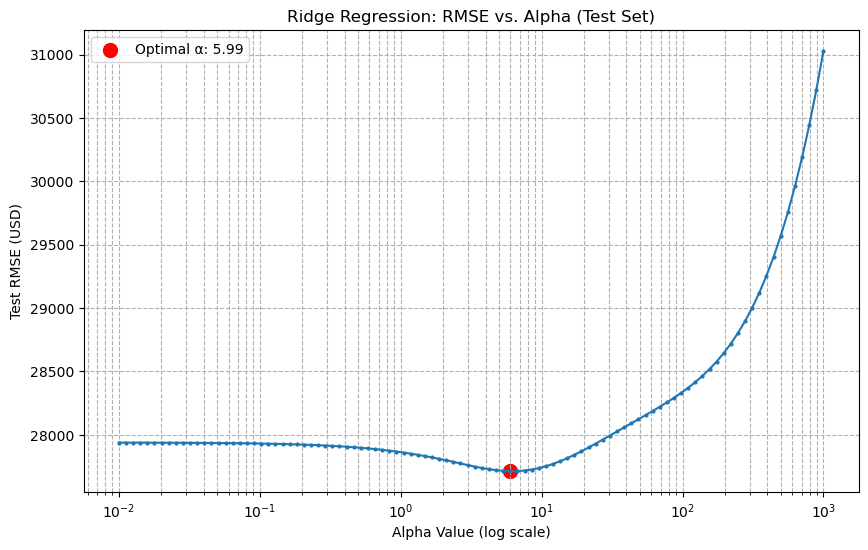

In [94]:
best_ridge_alpha_result = tune_ridge_alpha(X_train_scaled, X_test_scaled, y_train, y_test)
